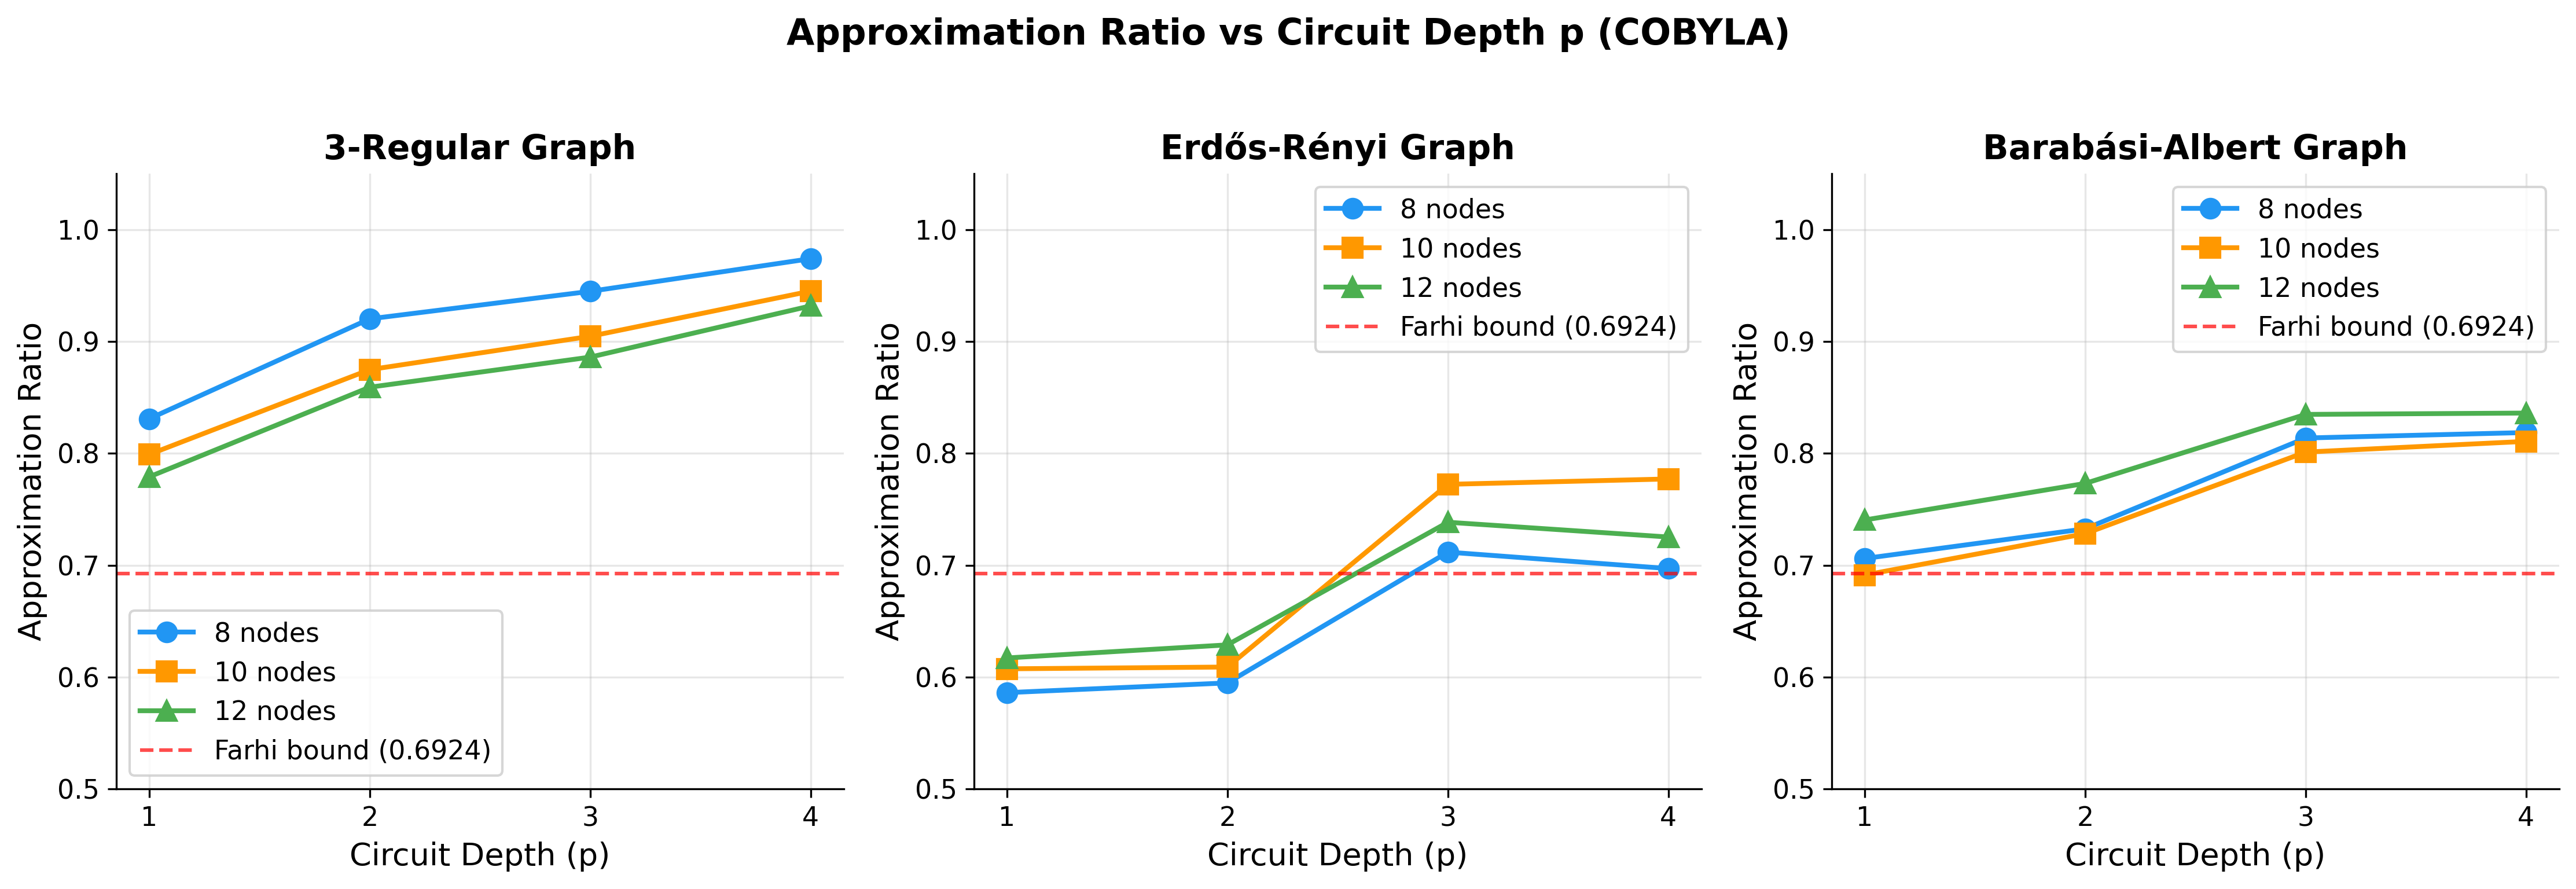

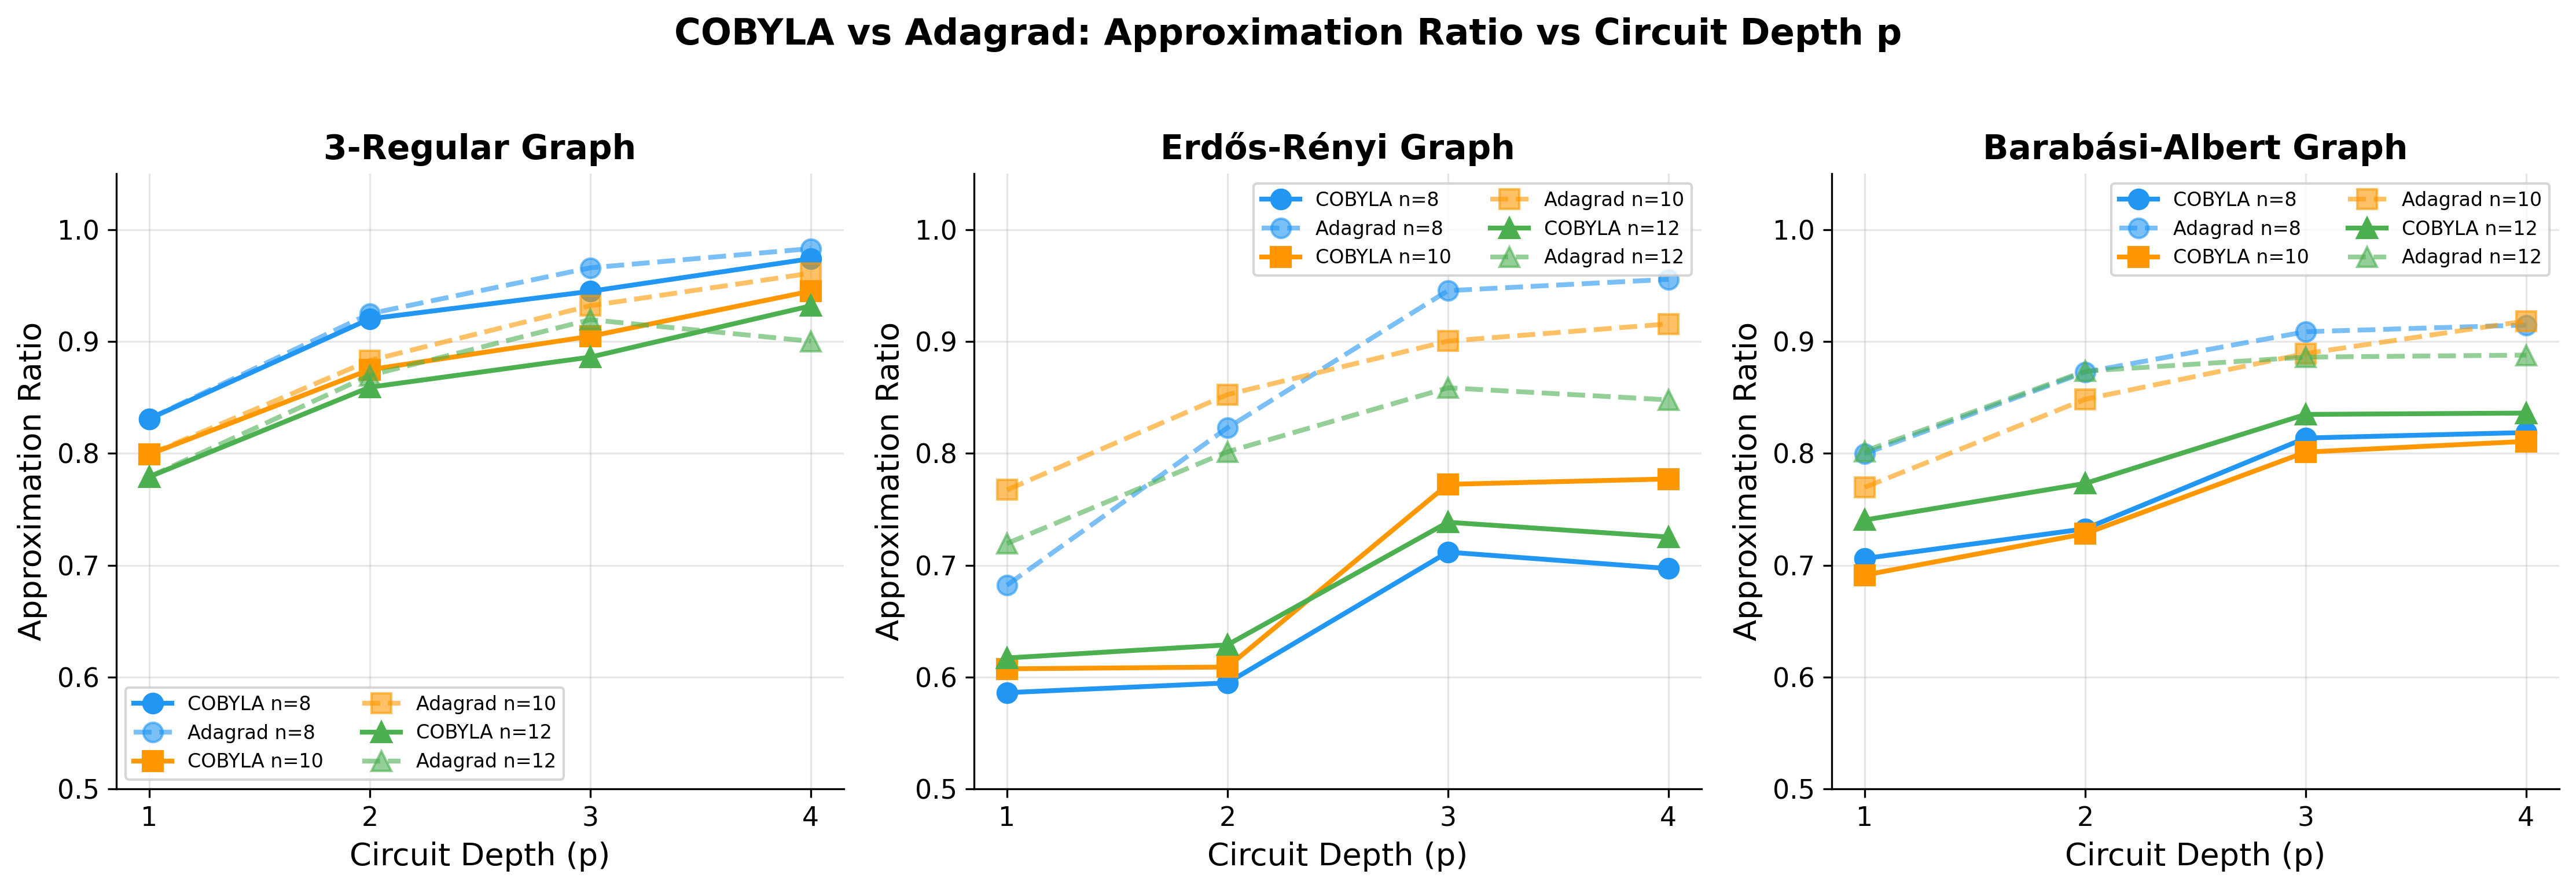

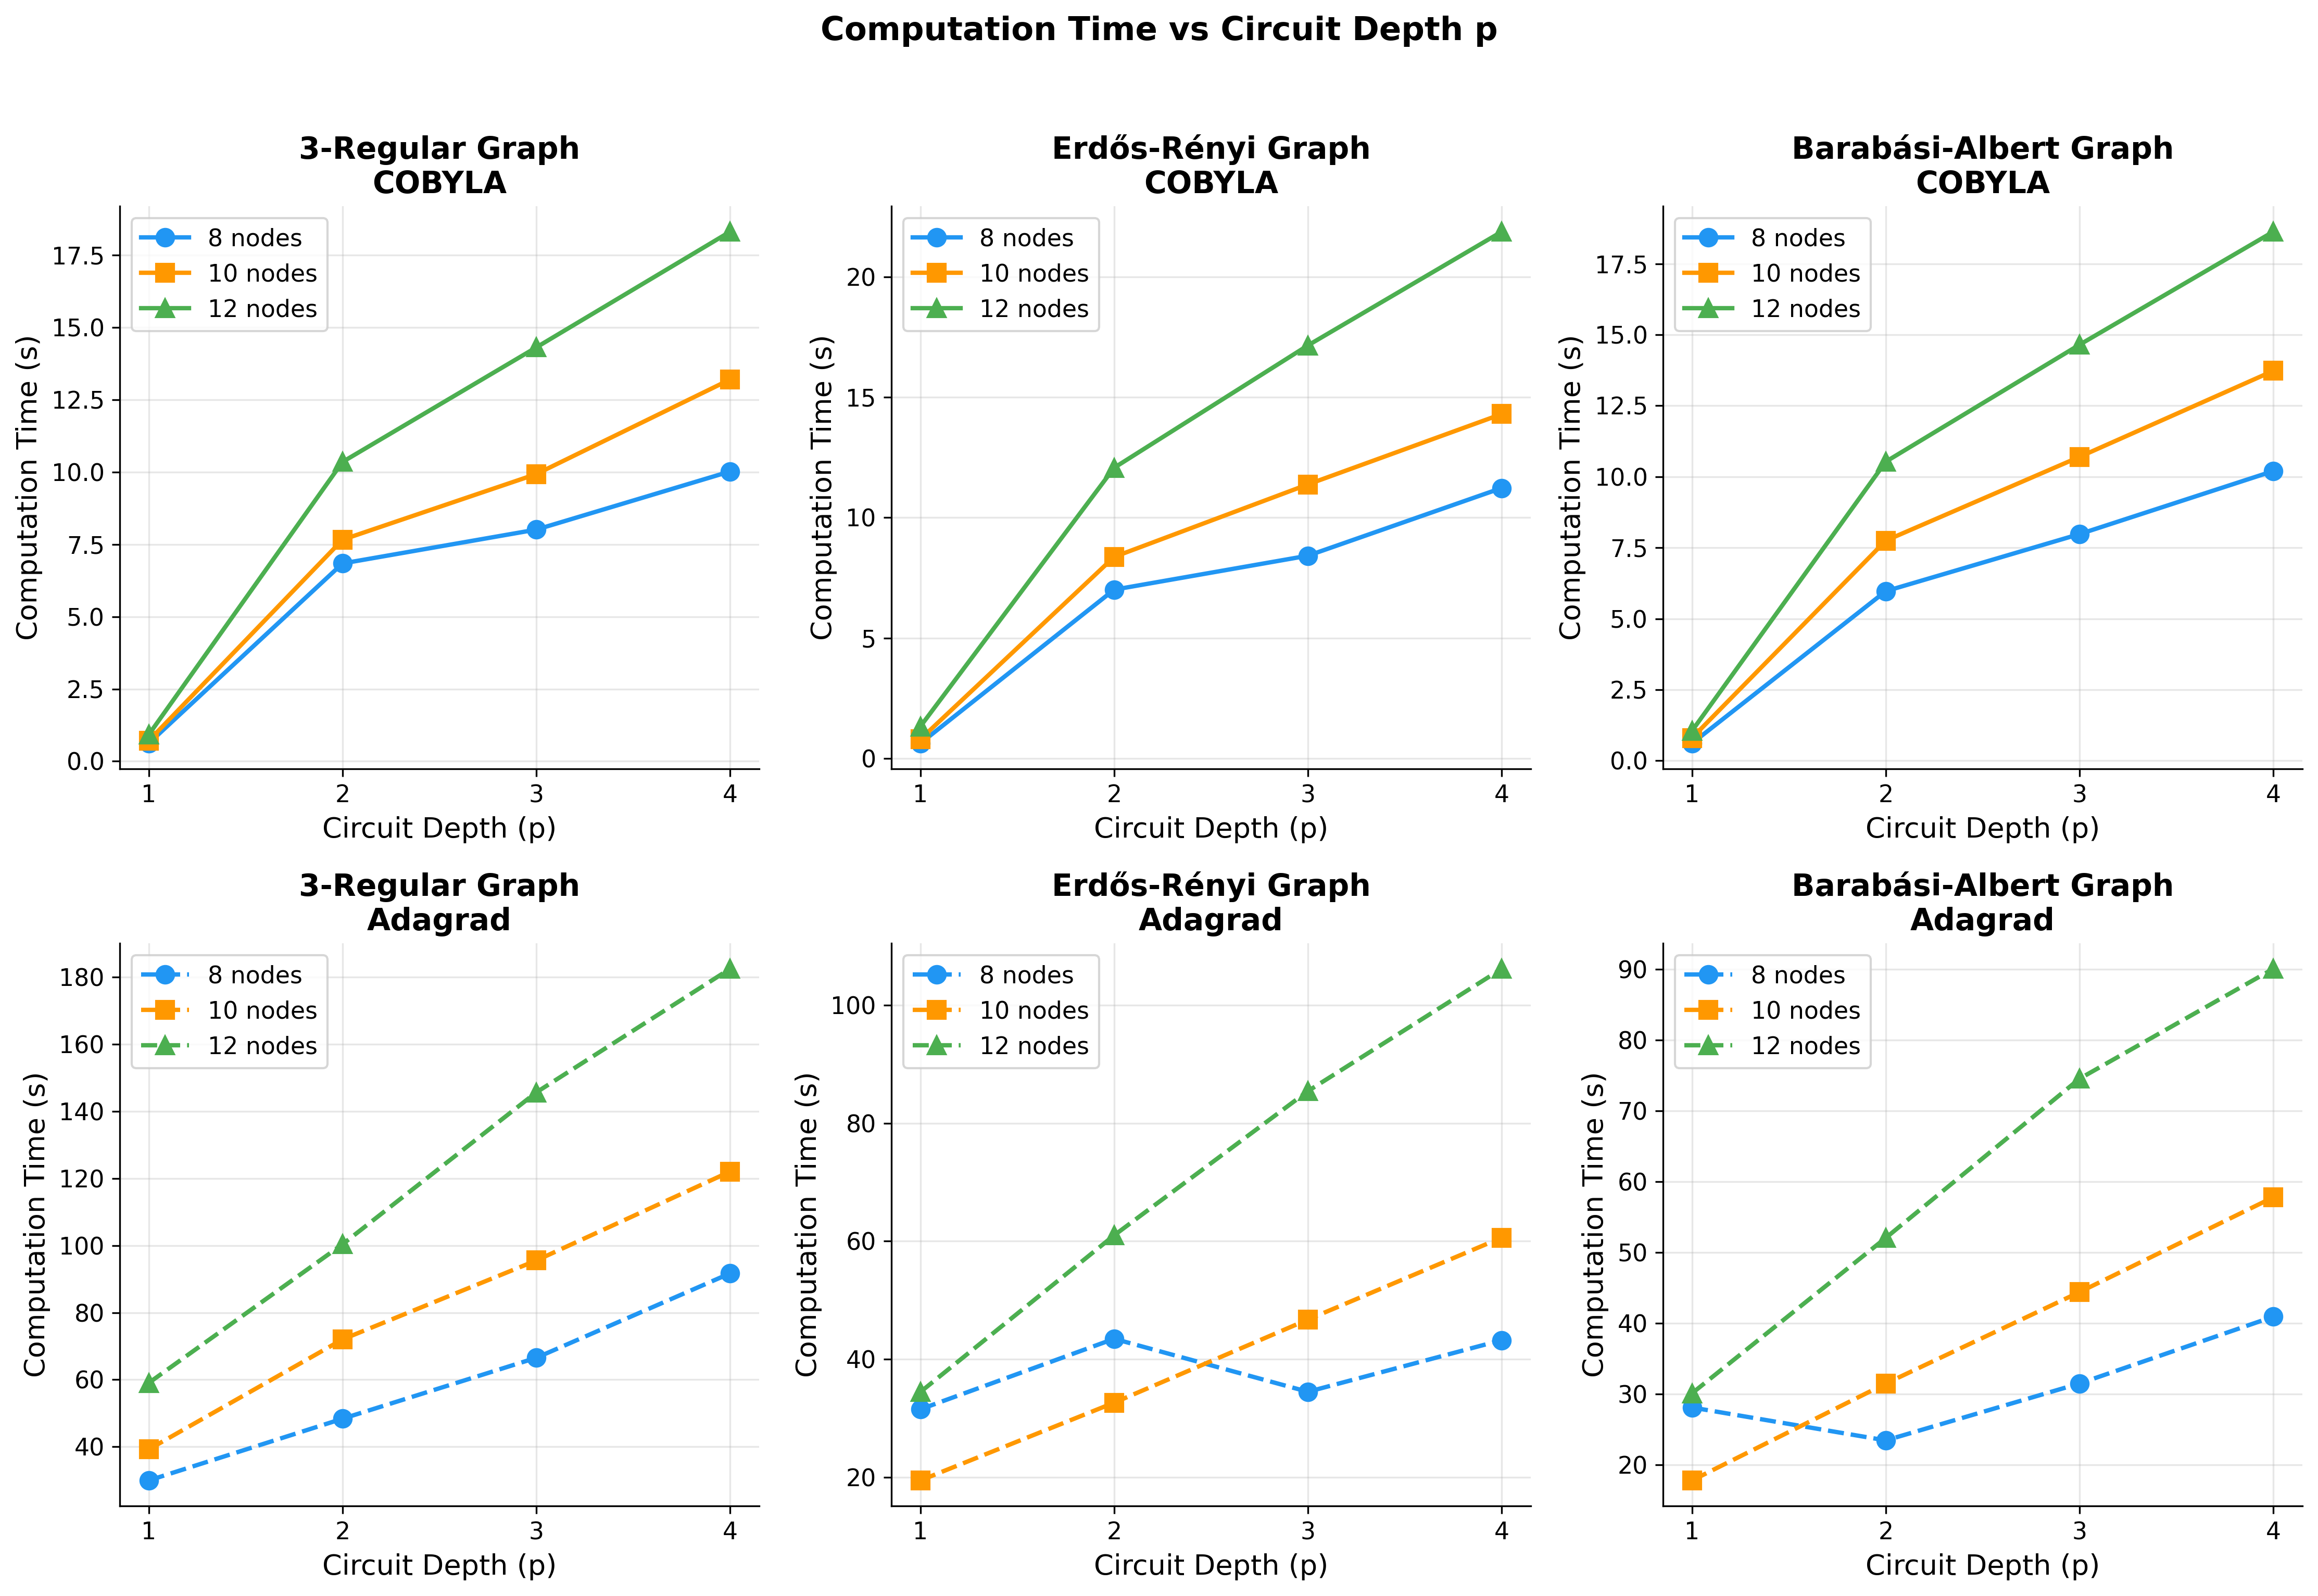

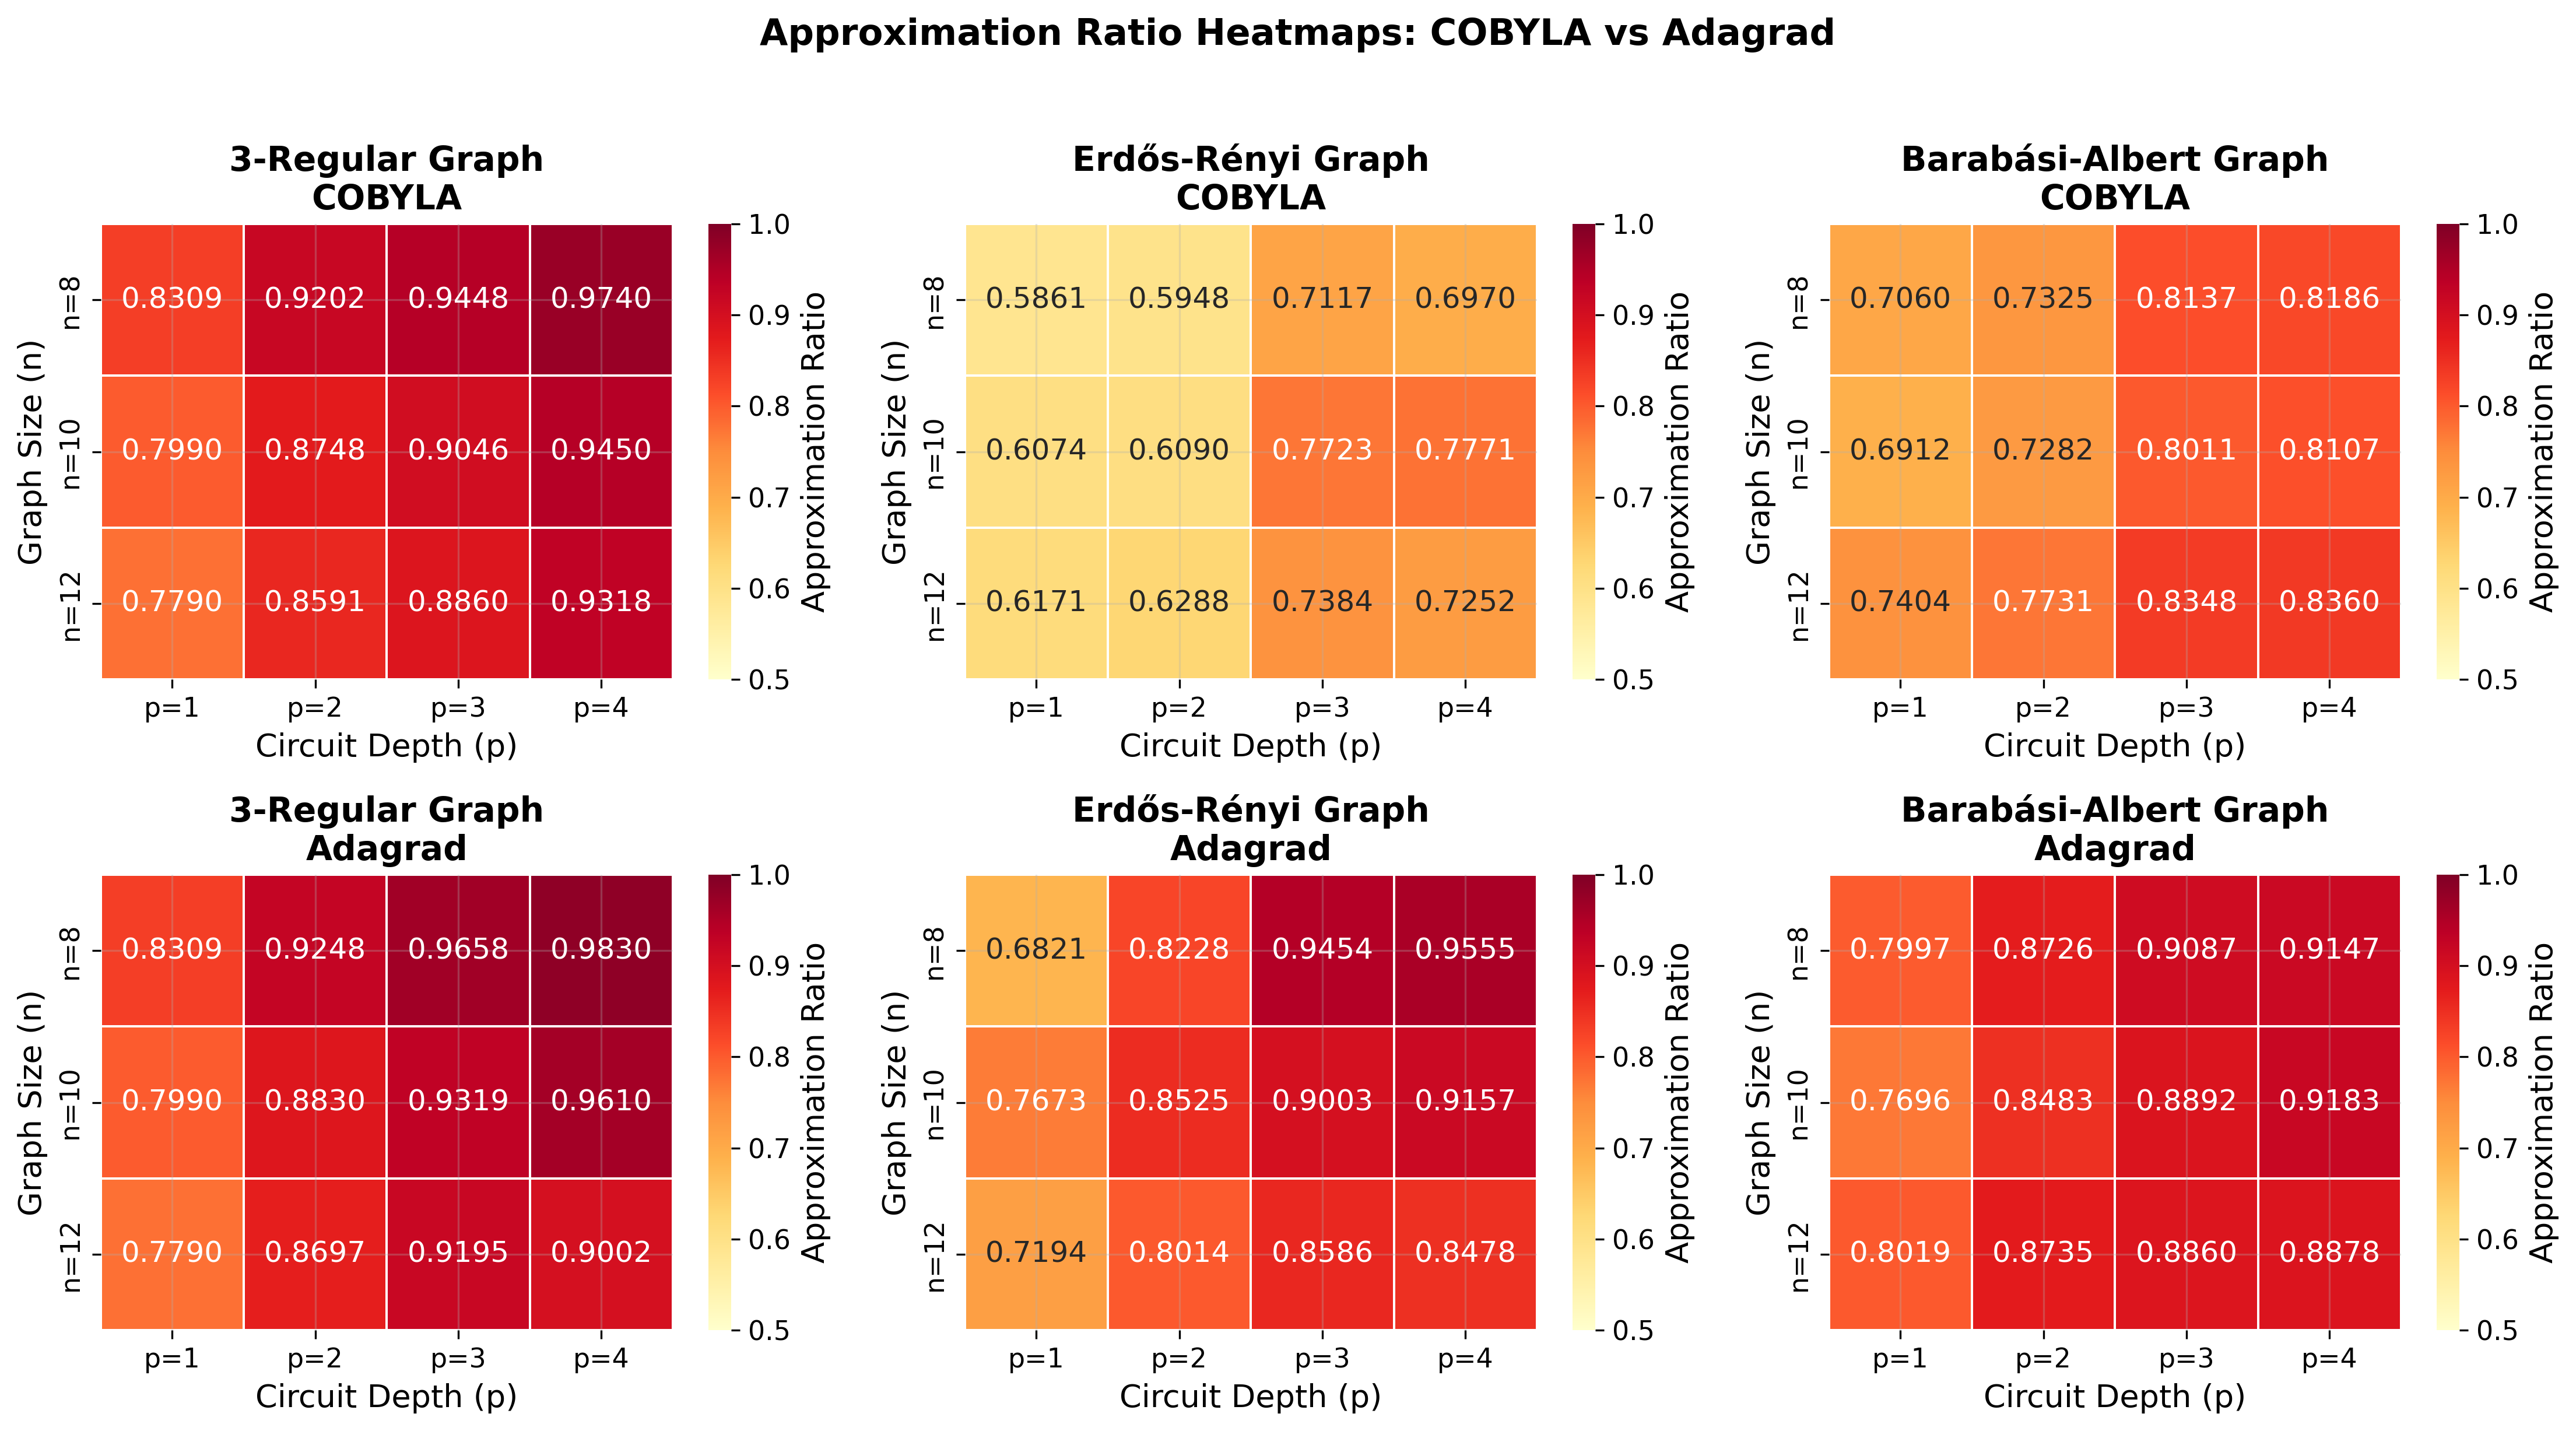

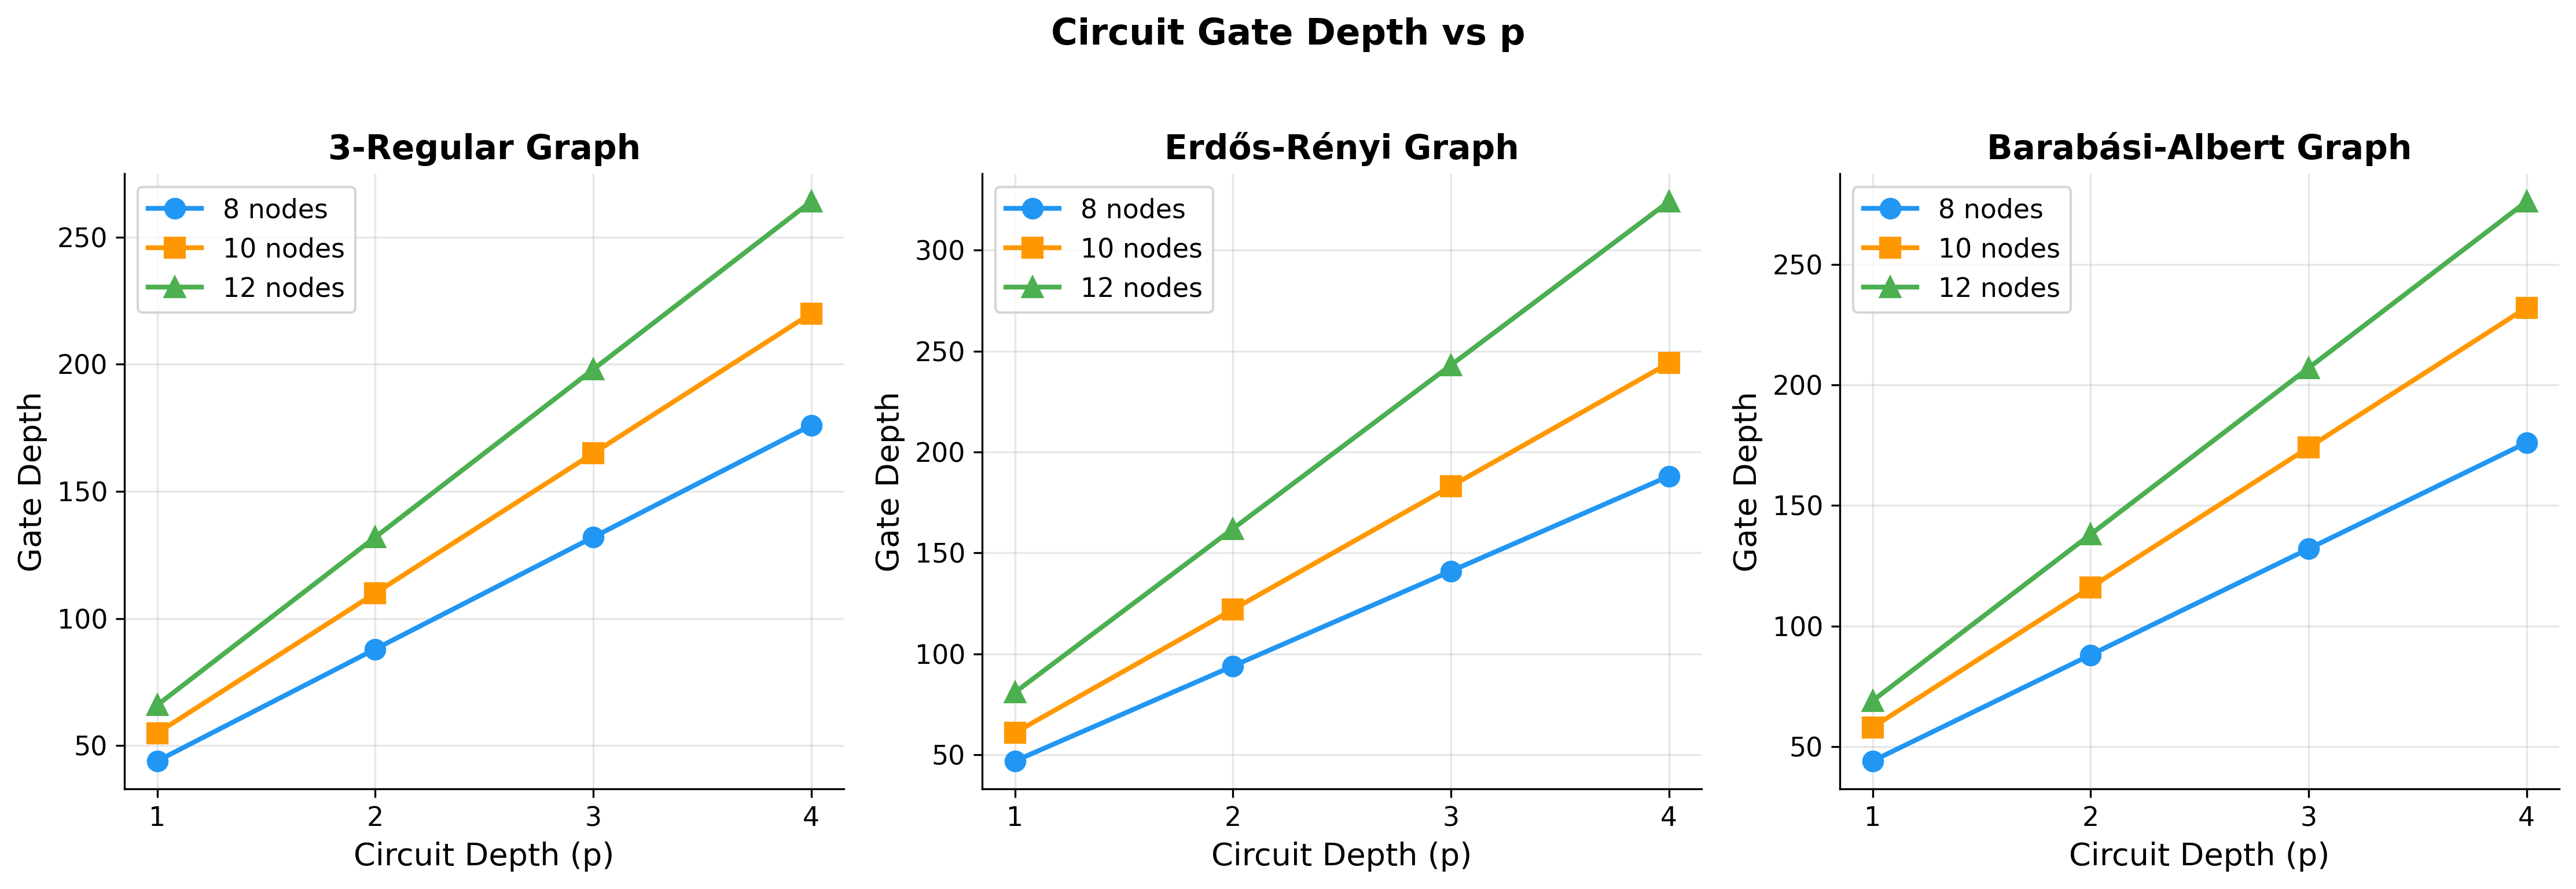

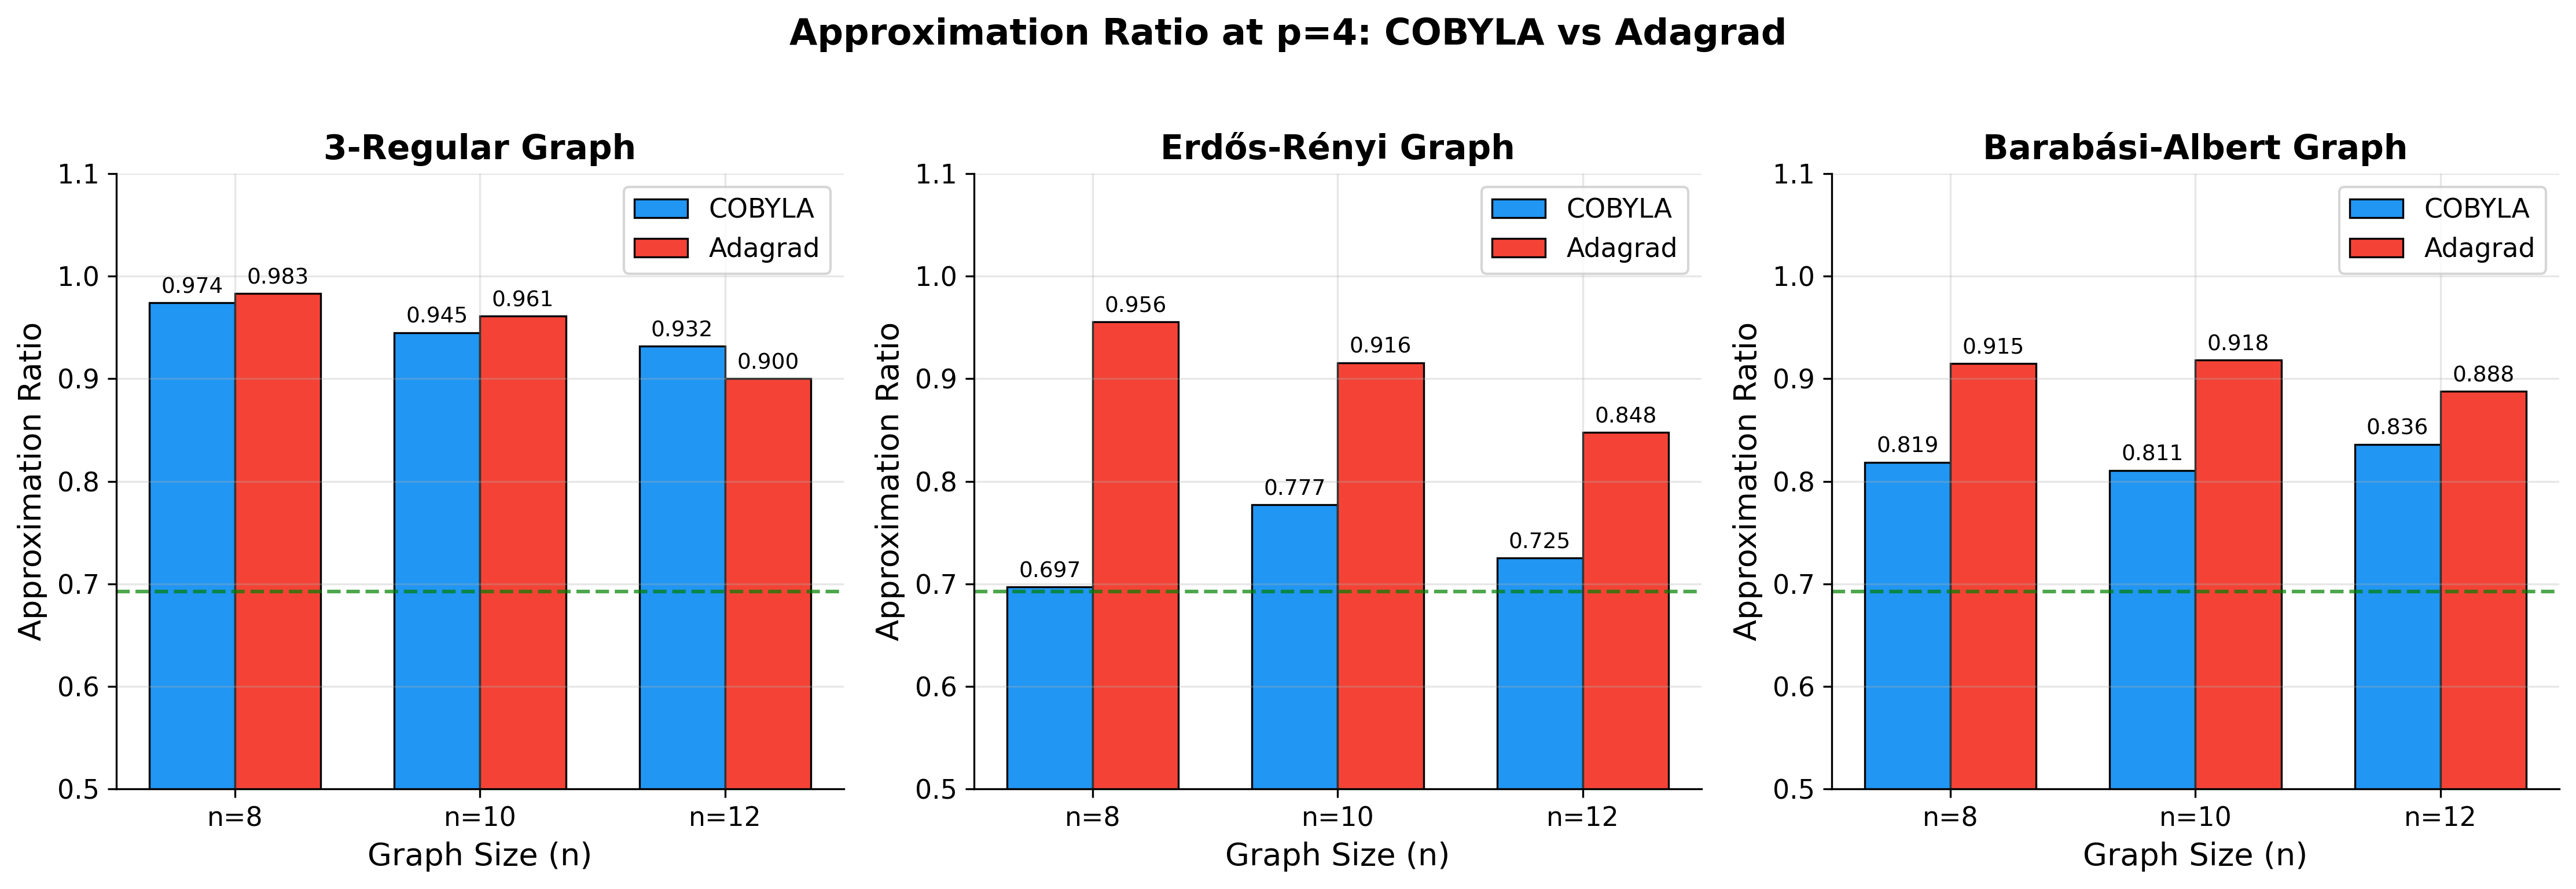

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =============================================
# Professional Style Setup
# =============================================
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# =============================================
# Data
# =============================================
p_values = [1, 2, 3, 4]
node_sizes = [8, 10, 12]

colors = {
    8:  '#2196F3',
    10: '#FF9800',
    12: '#4CAF50'
}

markers = {
    8:  'o',
    10: 's',
    12: '^'
}

# ---------- COBYLA ----------
cobyla = {
    '3-Regular': {
        8:  {'ratio': [0.8309, 0.9202, 0.9448, 0.9740],
             'time':  [0.62,   6.84,   8.01,  10.02],
             'depth': [44,     88,    132,    176]},
        10: {'ratio': [0.7990, 0.8748, 0.9046, 0.9450],
             'time':  [0.71,   7.66,   9.93,  13.20],
             'depth': [55,    110,    165,    220]},
        12: {'ratio': [0.7790, 0.8591, 0.8860, 0.9318],
             'time':  [0.92,  10.35,  14.31,  18.31],
             'depth': [66,    132,    198,    264]}
    },
    'Erdos-Renyi': {
        8:  {'ratio': [0.5861, 0.5948, 0.7117, 0.6970],
             'time':  [0.63,   7.01,   8.42,  11.23],
             'depth': [47,     94,    141,    188]},
        10: {'ratio': [0.6074, 0.6090, 0.7723, 0.7771],
             'time':  [0.80,   8.37,  11.38,  14.30],
             'depth': [61,    122,    183,    244]},
        12: {'ratio': [0.6171, 0.6288, 0.7384, 0.7252],
             'time':  [1.33,  12.07,  17.15,  21.87],
             'depth': [81,    162,    243,    324]}
    },
    'Barabasi-Albert': {
        8:  {'ratio': [0.7060, 0.7325, 0.8137, 0.8186],
             'time':  [0.61,   5.97,   7.98,  10.20],
             'depth': [44,     88,    132,    176]},
        10: {'ratio': [0.6912, 0.7282, 0.8011, 0.8107],
             'time':  [0.80,   7.75,  10.70,  13.73],
             'depth': [58,    116,    174,    232]},
        12: {'ratio': [0.7404, 0.7731, 0.8348, 0.8360],
             'time':  [1.05,  10.53,  14.65,  18.63],
             'depth': [69,    138,    207,    276]}
    }
}

# ---------- Adagrad ----------
adagrad = {
    '3-Regular': {
        8:  {'ratio': [0.8309, 0.9248, 0.9658, 0.9830],
             'time':  [29.96, 48.36,  66.52,  91.69],
             'depth': [44,    88,    132,    176]},
        10: {'ratio': [0.7990, 0.8830, 0.9319, 0.9610],
             'time':  [39.22, 72.00,  95.53, 122.03],
             'depth': [55,   110,    165,    220]},
        12: {'ratio': [0.7790, 0.8697, 0.9195, 0.9002],
             'time':  [59.03,100.36, 145.64, 182.48],
             'depth': [66,   132,    198,    264]}
    },
    'Erdos-Renyi': {
        8:  {'ratio': [0.6821, 0.8228, 0.9454, 0.9555],
             'time':  [31.49, 43.44,  34.46,  43.21],
             'depth': [47,    94,    141,    188]},
        10: {'ratio': [0.7673, 0.8525, 0.9003, 0.9157],
             'time':  [19.43, 32.61,  46.70,  60.59],
             'depth': [61,   122,    183,    244]},
        12: {'ratio': [0.7194, 0.8014, 0.8586, 0.8478],
             'time':  [34.42, 60.98,  85.43, 106.16],
             'depth': [81,   162,    243,    324]}
    },
    'Barabasi-Albert': {
        8:  {'ratio': [0.7997, 0.8726, 0.9087, 0.9147],
             'time':  [28.08, 23.43,  31.47,  40.91],
             'depth': [44,    88,    132,    176]},
        10: {'ratio': [0.7696, 0.8483, 0.8892, 0.9183],
             'time':  [17.77, 31.46,  44.38,  57.78],
             'depth': [58,   116,    174,    232]},
        12: {'ratio': [0.8019, 0.8735, 0.8860, 0.8878],
             'time':  [30.08, 52.04,  74.53,  90.06],
             'depth': [69,   138,    207,    276]}
    }
}

graph_titles = {
    '3-Regular': '3-Regular Graph',
    'Erdos-Renyi': 'Erdős-Rényi Graph',
    'Barabasi-Albert': 'Barabási-Albert Graph'
}

graph_keys = ['3-Regular', 'Erdos-Renyi', 'Barabasi-Albert']

# =============================================
# Plot 1: Approximation Ratio vs p
# one row per graph type, COBYLA only
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, gtype in enumerate(graph_keys):
    ax = axes[idx]
    for n in node_sizes:
        ax.plot(
            p_values,
            cobyla[gtype][n]['ratio'],
            color=colors[n],
            marker=markers[n],
            linewidth=2,
            markersize=8,
            label=f'{n} nodes'
        )
    ax.set_title(graph_titles[gtype], fontweight='bold')
    ax.set_xlabel('Circuit Depth (p)')
    ax.set_ylabel('Approximation Ratio')
    ax.set_xticks(p_values)
    ax.set_ylim(0.5, 1.05)
    ax.axhline(
        y=0.6924,
        color='red',
        linestyle='--',
        linewidth=1.5,
        alpha=0.7,
        label='Farhi bound (0.6924)'
    )
    ax.legend()

plt.suptitle(
    'Approximation Ratio vs Circuit Depth p (COBYLA)',
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('approx_ratio_vs_p_cobyla.pdf')
plt.show()

# =============================================
# Plot 2: COBYLA vs Adagrad Comparison
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

linestyles = {
    'COBYLA': '-',
    'Adagrad': '--'
}

opt_colors = {
    'COBYLA':  '#2196F3',
    'Adagrad': '#F44336'
}

for idx, gtype in enumerate(graph_keys):
    ax = axes[idx]
    for n in node_sizes:
        # COBYLA
        ax.plot(
            p_values,
            cobyla[gtype][n]['ratio'],
            color=colors[n],
            marker=markers[n],
            linewidth=2,
            markersize=8,
            linestyle='-',
            label=f'COBYLA n={n}'
        )
        # Adagrad
        ax.plot(
            p_values,
            adagrad[gtype][n]['ratio'],
            color=colors[n],
            marker=markers[n],
            linewidth=2,
            markersize=8,
            linestyle='--',
            alpha=0.6,
            label=f'Adagrad n={n}'
        )

    ax.set_title(graph_titles[gtype], fontweight='bold')
    ax.set_xlabel('Circuit Depth (p)')
    ax.set_ylabel('Approximation Ratio')
    ax.set_xticks(p_values)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=8, ncol=2)

plt.suptitle(
    'COBYLA vs Adagrad: Approximation Ratio vs Circuit Depth p',
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('cobyla_vs_adagrad.pdf')
plt.show()

# =============================================
# Plot 3: Computation Time vs p
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, gtype in enumerate(graph_keys):
    # COBYLA time
    ax_cobyla = axes[0][idx]
    for n in node_sizes:
        ax_cobyla.plot(
            p_values,
            cobyla[gtype][n]['time'],
            color=colors[n],
            marker=markers[n],
            linewidth=2,
            markersize=8,
            label=f'{n} nodes'
        )
    ax_cobyla.set_title(
        f'{graph_titles[gtype]}\nCOBYLA',
        fontweight='bold'
    )
    ax_cobyla.set_xlabel('Circuit Depth (p)')
    ax_cobyla.set_ylabel('Computation Time (s)')
    ax_cobyla.set_xticks(p_values)
    ax_cobyla.legend()

    # Adagrad time
    ax_adagrad = axes[1][idx]
    for n in node_sizes:
        ax_adagrad.plot(
            p_values,
            adagrad[gtype][n]['time'],
            color=colors[n],
            marker=markers[n],
            linewidth=2,
            markersize=8,
            linestyle='--',
            label=f'{n} nodes'
        )
    ax_adagrad.set_title(
        f'{graph_titles[gtype]}\nAdagrad',
        fontweight='bold'
    )
    ax_adagrad.set_xlabel('Circuit Depth (p)')
    ax_adagrad.set_ylabel('Computation Time (s)')
    ax_adagrad.set_xticks(p_values)
    ax_adagrad.legend()

plt.suptitle(
    'Computation Time vs Circuit Depth p',
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('computation_time_vs_p.pdf')
plt.show()

# =============================================
# Plot 4: Heatmaps of Approximation Ratios
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, gtype in enumerate(graph_keys):
    # COBYLA heatmap
    data_cobyla = np.array([
        cobyla[gtype][n]['ratio'] for n in node_sizes
    ])
    ax = axes[0][idx]
    sns.heatmap(
        data_cobyla,
        ax=ax,
        annot=True,
        fmt='.4f',
        cmap='YlOrRd',
        xticklabels=[f'p={p}' for p in p_values],
        yticklabels=[f'n={n}' for n in node_sizes],
        vmin=0.5,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={'label': 'Approximation Ratio'}
    )
    ax.set_title(
        f'{graph_titles[gtype]}\nCOBYLA',
        fontweight='bold'
    )
    ax.set_xlabel('Circuit Depth (p)')
    ax.set_ylabel('Graph Size (n)')

    # Adagrad heatmap
    data_adagrad = np.array([
        adagrad[gtype][n]['ratio'] for n in node_sizes
    ])
    ax = axes[1][idx]
    sns.heatmap(
        data_adagrad,
        ax=ax,
        annot=True,
        fmt='.4f',
        cmap='YlOrRd',
        xticklabels=[f'p={p}' for p in p_values],
        yticklabels=[f'n={n}' for n in node_sizes],
        vmin=0.5,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={'label': 'Approximation Ratio'}
    )
    ax.set_title(
        f'{graph_titles[gtype]}\nAdagrad',
        fontweight='bold'
    )
    ax.set_xlabel('Circuit Depth (p)')
    ax.set_ylabel('Graph Size (n)')

plt.suptitle(
    'Approximation Ratio Heatmaps: COBYLA vs Adagrad',
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('heatmaps_approx_ratio.pdf')
plt.show()

# =============================================
# Plot 5: Circuit Depth vs p
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, gtype in enumerate(graph_keys):
    ax = axes[idx]
    for n in node_sizes:
        ax.plot(
            p_values,
            cobyla[gtype][n]['depth'],
            color=colors[n],
            marker=markers[n],
            linewidth=2,
            markersize=8,
            label=f'{n} nodes'
        )
    ax.set_title(graph_titles[gtype], fontweight='bold')
    ax.set_xlabel('Circuit Depth (p)')
    ax.set_ylabel('Gate Depth')
    ax.set_xticks(p_values)
    ax.legend()

plt.suptitle(
    'Circuit Gate Depth vs p',
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('circuit_depth_vs_p.pdf')
plt.show()

# =============================================
# Plot 6: Bar Chart Summary at p=4
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x = np.arange(len(node_sizes))
width = 0.35

for idx, gtype in enumerate(graph_keys):
    ax = axes[idx]

    cobyla_ratios  = [cobyla[gtype][n]['ratio'][3]  
                      for n in node_sizes]
    adagrad_ratios = [adagrad[gtype][n]['ratio'][3] 
                      for n in node_sizes]

    bars1 = ax.bar(
        x - width/2,
        cobyla_ratios,
        width,
        label='COBYLA',
        color='#2196F3',
        edgecolor='black',
        linewidth=0.8
    )
    bars2 = ax.bar(
        x + width/2,
        adagrad_ratios,
        width,
        label='Adagrad',
        color='#F44336',
        edgecolor='black',
        linewidth=0.8
    )

    # Value labels on bars
    for bar in bars1:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )
    for bar in bars2:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_title(graph_titles[gtype], fontweight='bold')
    ax.set_xlabel('Graph Size (n)')
    ax.set_ylabel('Approximation Ratio')
    ax.set_xticks(x)
    ax.set_xticklabels([f'n={n}' for n in node_sizes])
    ax.set_ylim(0.5, 1.1)
    ax.legend()
    ax.axhline(
        y=0.6924,
        color='green',
        linestyle='--',
        linewidth=1.5,
        alpha=0.7,
        label='Farhi bound'
    )

plt.suptitle(
    'Approximation Ratio at p=4: COBYLA vs Adagrad',
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('bar_chart_p4.pdf')
plt.show()